In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
year = 2017
train,unnorm,mass,names = hf.LAPS_train("DATA",year,num_batches=40,Mjj_cut=800,pt_cut=300,sideband=True)
mass = mass.flatten()

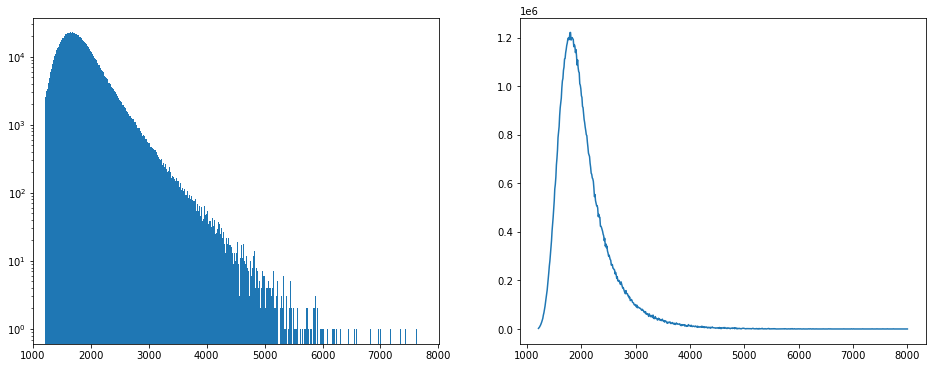

In [3]:
plt.figure(figsize=(16,6))
step = 10
bins = bins=np.arange(1200,8000+step,step)
plt.subplot(121)
counts,bins,patch = plt.hist(mass,bins=bins)
plt.xlim([1000,8000+step])
plt.yscale('log')

upperLims = bins[1:]
possibleWithUniform = []
for i,ct in enumerate(counts):
    nbins = i+1
    ntot = nbins*ct
    possibleWithUniform.append(ntot)
possibleWithUniform = np.array(possibleWithUniform)
plt.subplot(122)
plt.plot(upperLims,possibleWithUniform)

mMax = upperLims[np.max(np.where((possibleWithUniform-100000)>0)[0])]

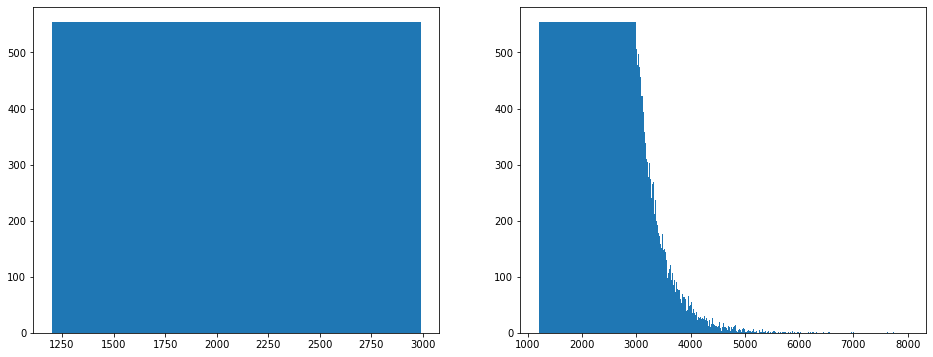

In [4]:
itail = (mass >= mMax).nonzero()
tail = train[itail]
mtail = mass[itail]

ibulk = (mass < mMax).nonzero()
bulk = train[ibulk]
mbulk = mass[ibulk]

# sample uniformly from bulk
bins = np.arange(1200,mMax+step,step)
nBins = len(bins)-1
bulkBins = np.digitize(mbulk,bins)
nToSample = np.min([len(bulkBins[bulkBins==i]) for i in range(1,nBins+1)])
sampleInds = [(bulkBins==i).nonzero()[0][:nToSample] for i in range(1,nBins+1)]
sample = np.concatenate([bulk[inds] for inds in sampleInds],axis=0)
mSample = np.concatenate([mbulk[inds] for inds in sampleInds],axis=0)

plt.figure(figsize=(16,6))
plt.subplot(121)
h = plt.hist(mSample,bins)

totalSample = np.concatenate((sample,tail),axis=0)
totalMass = np.concatenate((mSample,mtail),axis=0)
plt.subplot(122)
h = plt.hist(totalMass,bins=np.arange(1200,8000+step,step))

Initial: 120825 events 
Final: 120642 events 
Removed 0.1515%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Loss:  67.3974
Loss:  54.937256
Loss:  46.95384
Loss:  41.722954
Loss:  37.73329
Loss:  34.876537
Loss:  32.782005
Loss:  30.571655
Loss:  29.392017
Loss:  28.633924
Loss:  27.473787
Loss:  27.053974
Loss:  25.868622
Loss:  25.341522
Loss:  24.636936
Loss:  24.251757
Loss:  23.530056
Loss:  22.724983
Loss:  23.196863
Iteration 20 Complete
Loss:  22.568827
SAVING MODEL
Time:  32.16672468185425
------------------------------------
Loss:  22.34036
Loss:  21.388683
Loss:  21.184046
Loss:  21.313189
Loss:  21.004992
Loss:  20.499634
Loss:  20.189571
Loss:  19.905798
Loss:  19.544453
Loss:  19.552929
Loss:  19.489346
Loss:  19.903877
Loss:  19.37553
Loss:  19.107723
Loss:  19.126713
Loss:  18.481447
Loss:  18.550209
Loss:  18.465963
Loss:  17.915121
Iteration 40 Complete
Loss:  17.791191
SAVING MODEL
Time:  63.49377775192261
------------------------

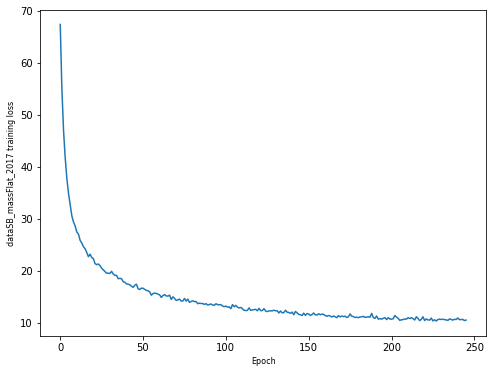

In [5]:
train_params = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":120,"num_layers":6,"num_blocks_per_layer":4,
                "clip":10,"patience":20,"learning_rate":2e-5,"save_model":True,"bs":10000,"nmax":100000}

with h5py.File("bkgMeanStds/dataSB_{0}.h5".format(year),"r") as f:
    mean = f["mean"][()]
    std = f["std"][()]

norm = np.copy(totalSample)
norm = hf.normalize_data(norm,inp_mean=mean,inp_std=std)

flow = hf.train_pipeline("dataSB_massFlat_{0}".format(year),norm,names,train_params,pt_cut=300,Mjj_cut=800)

# Density Estimation Performance

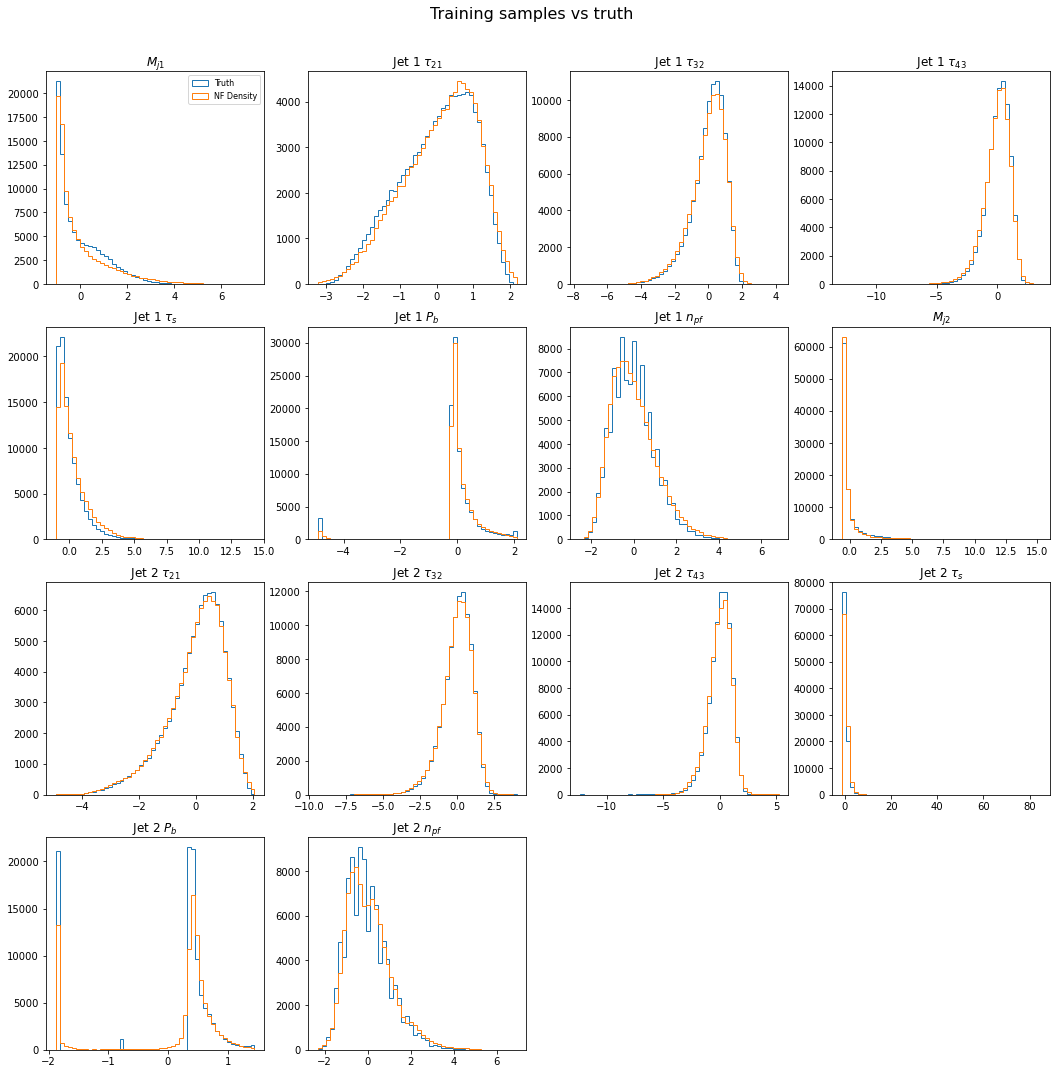

In [4]:
flow = hf.load_model(name="dataSB_massFlat_{0}_clip10_NSRATQUAD_k6_hf120_nbpl4_tb10_pt300.pt".format(year))
with h5py.File("bkgMeanStds/dataSB_{0}.h5".format(year),"r") as f:
    mean = f["mean"][()]
    std = f["std"][()]
train = train[:100000]
train = hf.normalize_data(train,inp_mean=mean,inp_std=std)
hf.plot_density_estimation(flow,train,names)